In [ ]:
from pathlib import Path

from generative_physics.config import TrainingConfig
from generative_physics.run import run_training

vae_lora_dir = Path("ks_vae_lora")
vae_lora_candidates = list(vae_lora_dir.glob("step-*.safetensors"))
final_vae_lora = vae_lora_dir / "pytorch_lora_weights.safetensors"
if final_vae_lora.is_file():
    vae_lora_candidates.append(final_vae_lora)
if not vae_lora_candidates:
    raise FileNotFoundError(f"No VAE LoRA checkpoints found in {vae_lora_dir.resolve()}")
vae_lora_checkpoint = max(
    vae_lora_candidates,
    key=lambda path: (path.stat().st_mtime_ns, path.name),
)
print(f"Using VAE LoRA checkpoint: {vae_lora_checkpoint.resolve()}")

config = TrainingConfig(
    pde_kind="ks",
    train_image_size=512,
    output_image_size=512,
    ks_grid_size=512,
    ks_condition_encoding="y_constant",
    ks_debug_num_samples=50,
    
    num_eval_pairs=8,

    stream_chunk_size=32,

    sim_num_workers=16,
    validate_every_n_steps=500,
    validation_num_images=8,

    run_initial_validation=True,
)


/home/ubuntu/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using VAE LoRA checkpoint: /home/ubuntu/generative_physics/ks_vae_lora/pytorch_lora_weights.safetensors


device=cuda, dtype=torch.bfloat16
Generating Kuramoto-Sivashinsky data: sim_nx=512, save_steps=512, image=512x512, initial_grid=256, sim_batch_size=256
Kuramoto-Sivashinsky: L=201.062, grid=512, frames=512, dt=0.00391389, burn_T=50, horizon_T=50, steps_per_frame=25, init_modes=32, init_decay=1, condition=top_strip, value_bounds=(-4.0, 4.0), cmap=gray
training data: streaming fresh simulations on the fly from seed 10000; no fixed training sample count
sample generation: CPU with 16 workers
generating fixed validation records...


Kuramoto-Sivashinsky CPU sims 20000: 100%|██████████| 50/50 [00:08<00:00,  5.88it/s]

generated 50 fixed eval records
validation seeds fixed at 20000..20049; streaming training skips that validation range
loading Flux pipeline



Loading pipeline components...: 100%|██████████| 5/5 [00:00<00:00,  6.25it/s]

loading VAE LoRA from /home/ubuntu/generative_physics/ks_vae_lora/pytorch_lora_weights.safetensors
pipeline loaded; moving pipeline to training device


pipeline on device; freezing base modules
encoding prompt
prompt encoded; moving text encoder to CPU
attaching LoRA adapters
scalar parameter conditioning: disabled
enabling gradient checkpointing
trainable transformer params: 39,034,880 / 3,914,579,456 (0.9972%)
parameter report:
  trainable: 39,034,880
    LoRA adapters: 39,034,880
    scalar AdaLN modulators: 0
    other transformer trainable: 0
  frozen: 7,985,483,043
    transformer base: 3,875,544,576
    VAE: 87,470,371
    text encoder: 4,022,468,096
initial validation inference before training


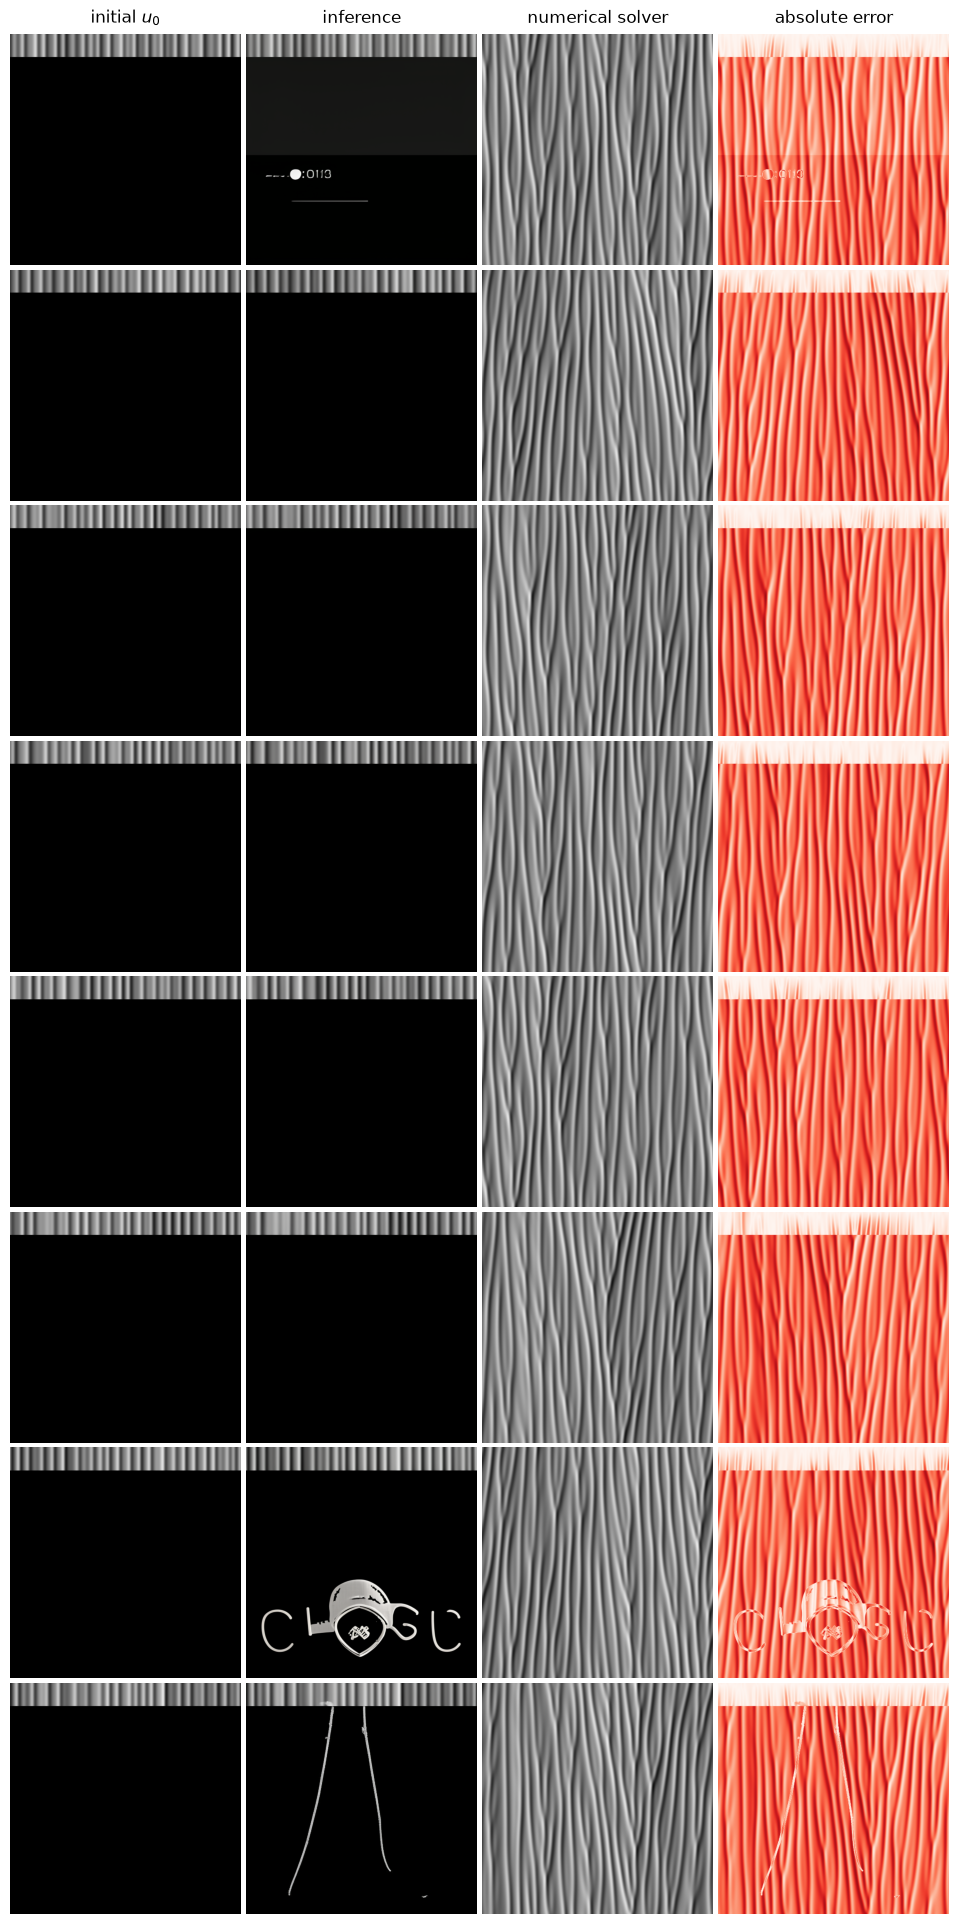

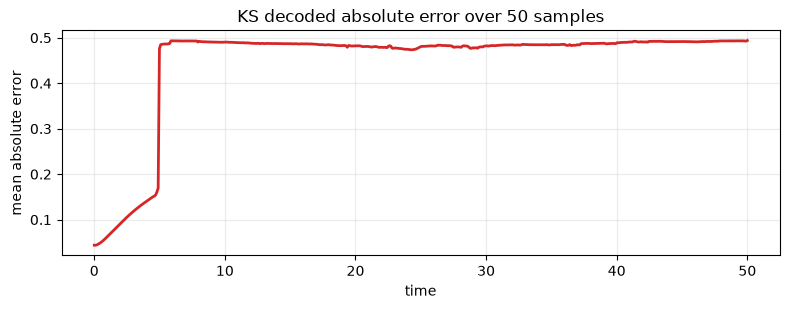

starting LoRA training; tqdm shows loss and ema
LoRA steps:   0%|          | 0/10001 [00:00<?, ?it/s] exact 4-step timesteps: [1000.0, 958.0853881835938, 883.9818725585938, 717.49658203125]
exact 4-step sigmas: [1.0, 0.95703125, 0.8828125, 0.71875]
validation inference at step 500                                                                                             
LoRA steps loss=0.0751 ema=0.0978:   5%|▍         | 500/10001 [08:47<2:44:50,  1.04s/it] , loss=0.0751 ema=0.0978 lr=2.98e-05

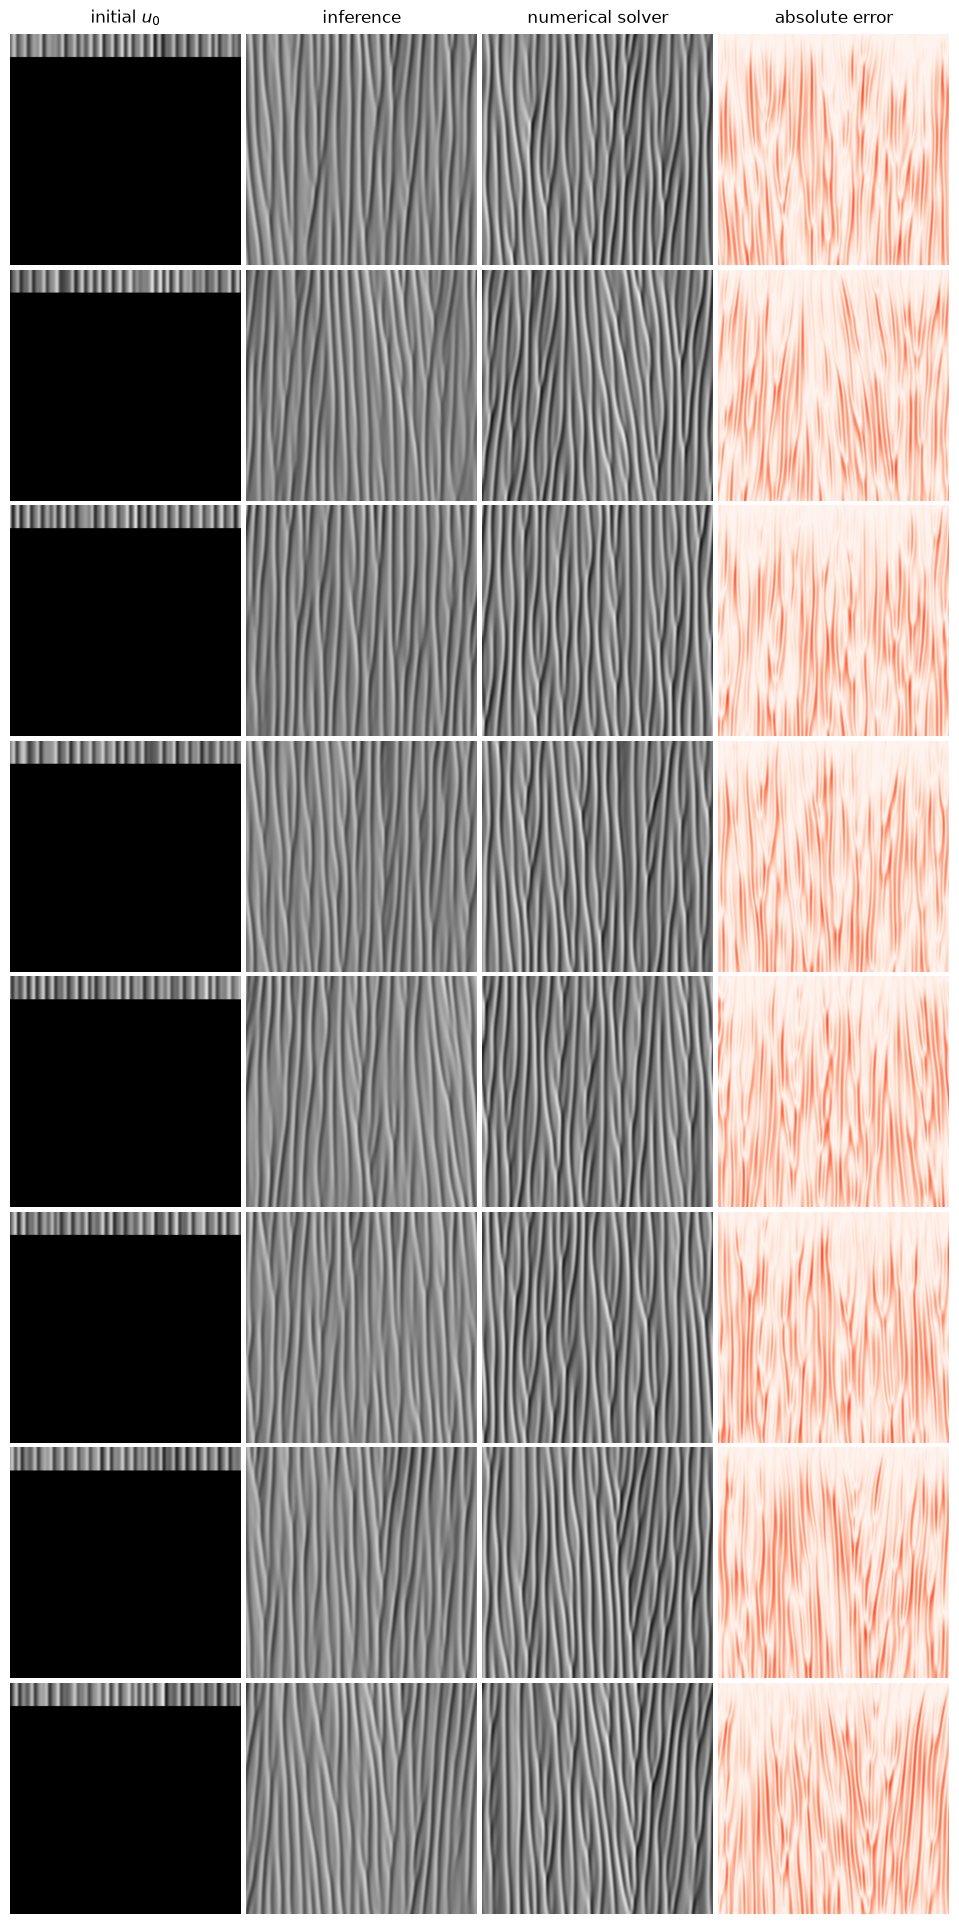

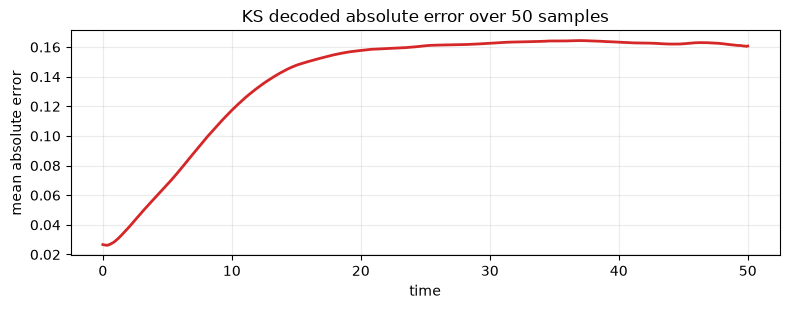

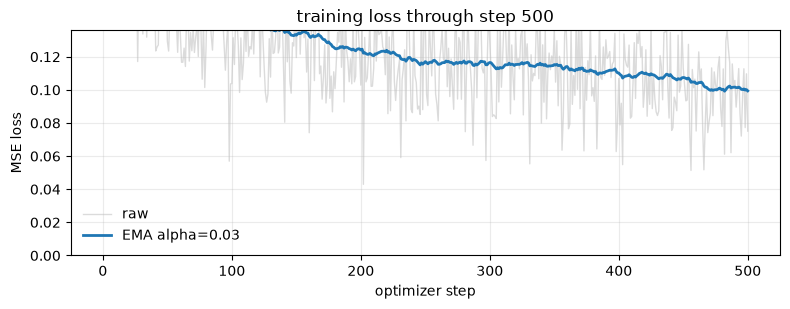

LoRA steps loss=0.0833 ema=0.0924:  10%|▉         | 989/10001 [17:40<2:41:03,  1.07s/it] , loss=0.0833 ema=0.0924 lr=2.93e-05 


KeyboardInterrupt: 

In [2]:
results = run_training(config, vae_lora_checkpoint=vae_lora_checkpoint)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

from generative_physics.ks import (
    KS_BURN_T,
    KS_CMAP_NAME,
    KS_DOMAIN_LENGTH,
    KS_DT,
    KS_GRID_SIZE,
    KS_HORIZON_T,
    KS_INITIAL_AMP,
    KS_INITIAL_DECAY,
    KS_INITIAL_NUM_MODES,
    KS_STEPS_PER_FRAME,
    KS_TIME_FRAMES,
    KS_VALUE_BOUNDS,
    array_to_flame_pil,
    augment_ks_symmetry,
    flame_image_to_normalized_array,
    ks_operators,
    ks_effective_discretization,
    random_spectral_ic,
    resize_ks_scalar_render,
)

KS_CONVERGENCE_SAMPLES = 50
KS_CONVERGENCE_RESOLUTIONS = (512, 1024, 2048)
KS_CONVERGENCE_REFERENCE = 2048
KS_CONVERGENCE_SEED_OFFSET = 30_000


@torch.no_grad()
def ks_integrate_cnab2_batch(u0, *, Lx, dt, Nt, nsave):
    u0 = u0.to(torch.float64)
    batch_size, nx = u0.shape
    G, A_inv, B = ks_operators(Nx=nx, Lx=Lx, dt=dt, device=u0.device)
    uhat = torch.fft.fft(u0, dim=-1)
    uhat[..., 0] = 0.0
    uhat[..., nx // 2] = 0.0

    def nonlinear(current_uhat):
        u = torch.fft.ifft(current_uhat, dim=-1).real
        value = G * torch.fft.fft(u * u, dim=-1)
        value[..., 0] = 0.0
        value[..., nx // 2] = 0.0
        return value

    nonlinear_previous = nonlinear(uhat)
    nonlinear_current = nonlinear_previous.clone()
    trajectory = torch.empty(
        (batch_size, Nt // nsave + 1, nx),
        device=u0.device,
        dtype=torch.float64,
    )
    trajectory[:, 0] = torch.fft.ifft(uhat, dim=-1).real
    output_index = 1
    for step in range(1, Nt + 1):
        uhat = A_inv * (
            B * uhat
            + 1.5 * dt * nonlinear_current
            - 0.5 * dt * nonlinear_previous
        )
        uhat[..., 0] = 0.0
        uhat[..., nx // 2] = 0.0
        nonlinear_previous = nonlinear_current
        nonlinear_current = nonlinear(uhat)
        if step % nsave == 0:
            trajectory[:, output_index] = torch.fft.ifft(uhat, dim=-1).real
            output_index += 1
    return trajectory


def decode_rendered_trajectories(trajectories, image_size):
    decoded = np.empty(
        (len(trajectories), image_size, image_size), dtype=np.float32
    )
    for sample_index, trajectory in enumerate(
        tqdm(trajectories, desc="decoding trajectories", leave=False)
    ):
        rendered = resize_ks_scalar_render(trajectory, image_size)
        image = array_to_flame_pil(
            rendered,
            value_bounds=KS_VALUE_BOUNDS,
            cmap_name=KS_CMAP_NAME,
        )
        decoded[sample_index] = 1.0 + flame_image_to_normalized_array(
            image, cmap_name=KS_CMAP_NAME
        )
    return decoded


simulation_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generators = []
spectral_initial_conditions = []
for sample_index in range(KS_CONVERGENCE_SAMPLES):
    generator = torch.Generator(device=simulation_device).manual_seed(
        KS_CONVERGENCE_SEED_OFFSET + sample_index
    )
    generators.append(generator)
    spectral_initial_conditions.append(
        random_spectral_ic(
            Nx=KS_CONVERGENCE_REFERENCE,
            n_modes=KS_INITIAL_NUM_MODES,
            decay=KS_INITIAL_DECAY,
            amp=KS_INITIAL_AMP,
            generator=generator,
            device=simulation_device,
        )
    )
spectral_initial_conditions = torch.stack(spectral_initial_conditions)

_, _, reference_dt = ks_effective_discretization(
    Nx=KS_GRID_SIZE, image_size=KS_CONVERGENCE_REFERENCE
)
burn_steps = int(round(KS_BURN_T / reference_dt))
burned = ks_integrate_cnab2_batch(
    spectral_initial_conditions,
    Lx=KS_DOMAIN_LENGTH,
    dt=reference_dt,
    Nt=burn_steps,
    nsave=burn_steps,
)[:, -1]
initial_reference = torch.stack(
    [augment_ks_symmetry(u, generator=g) for u, g in zip(burned, generators)]
)

reference_trajectory = ks_integrate_cnab2_batch(
    initial_reference,
    Lx=KS_DOMAIN_LENGTH,
    dt=reference_dt,
    Nt=(KS_CONVERGENCE_REFERENCE - 1) * KS_STEPS_PER_FRAME,
    nsave=KS_STEPS_PER_FRAME,
).cpu().numpy()
reference_decoded = decode_rendered_trajectories(
    reference_trajectory, KS_CONVERGENCE_REFERENCE
)

mean_relative_error = {}
for resolution in (512, 1024):
    _, _, resolution_dt = ks_effective_discretization(
        Nx=KS_GRID_SIZE, image_size=resolution
    )
    initial = initial_reference[:, :: KS_CONVERGENCE_REFERENCE // resolution].contiguous()
    trajectory = ks_integrate_cnab2_batch(
        initial,
        Lx=KS_DOMAIN_LENGTH,
        dt=resolution_dt,
        Nt=(resolution - 1) * KS_STEPS_PER_FRAME,
        nsave=KS_STEPS_PER_FRAME,
    ).cpu().numpy()
    decoded = decode_rendered_trajectories(trajectory, resolution)
    reference_on_grid = F.interpolate(
        torch.from_numpy(reference_decoded)[:, None],
        size=(resolution, resolution),
        mode="bilinear",
        align_corners=True,
    )[:, 0].numpy()
    numerator = np.linalg.norm(decoded - reference_on_grid, axis=-1)
    denominator = np.linalg.norm(reference_on_grid, axis=-1)
    relative_error = numerator / np.maximum(denominator, np.finfo(np.float32).eps)
    mean_relative_error[resolution] = relative_error.mean(axis=0)
    del trajectory, decoded, reference_on_grid, relative_error

fig, ax = plt.subplots(figsize=(8, 3.5))
for resolution in (512, 1024):
    times = np.linspace(0.0, KS_HORIZON_T, resolution)
    ax.plot(
        times,
        mean_relative_error[resolution],
        linewidth=2.0,
        label=f"{resolution} vs 1024",
    )
ax.set_xlabel("time")
ax.set_ylabel(r"$\mathbb{E}_u[\|u-u_{ref}\|_2/\|u_{ref}\|_2]$")
ax.set_title("KS resolution error at fixed L and T from 50 initial conditions")
ax.grid(True, alpha=0.25)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()
